In [2]:
# %% 1 - Imports
import os
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [31]:
# %% 2 - Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# %% 3 - Dataset Path
!unzip -q "/content/drive/MyDrive/Computer Vision/data.zip" -d /content/
dataset_root = "/content/data/png_ready"

print("Path exists:", os.path.exists(dataset_root))

replace /content/data/png_ready/present/13012.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Path exists: True


In [33]:
# %% 4 - Hyperparameters
img_size = 96
batch_size = 64
learning_rate = 3e-4
num_epochs = 60
val_split = 0.2
random_seed = 42

In [34]:
# %% 5 - Transforms

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((img_size, img_size)),
    transforms.RandomAffine(
        degrees=12,
        translate=(0.08, 0.08),
        scale=(0.9, 1.1)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [35]:
# %% 6 - Load Dataset
full_dataset = datasets.ImageFolder(root=dataset_root, transform=train_transform)

class_names = full_dataset.classes
num_classes = len(class_names)

print("Number of classes:", num_classes)
print("First 20 classes:", class_names[:20])
print("Total images:", len(full_dataset))

Number of classes: 250
First 20 classes: ['airplane', 'alarm clock', 'angel', 'ant', 'apple', 'arm', 'armchair', 'ashtray', 'axe', 'backpack', 'banana', 'barn', 'baseball bat', 'basket', 'bathtub', 'bear (animal)', 'bed', 'bee', 'beer-mug', 'bell']
Total images: 20000


In [36]:
# %% 7 - Train / Validation Split
torch.manual_seed(random_seed)

train_size = int((1 - val_split) * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset.transform = eval_transform

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 16000
Validation samples: 4000


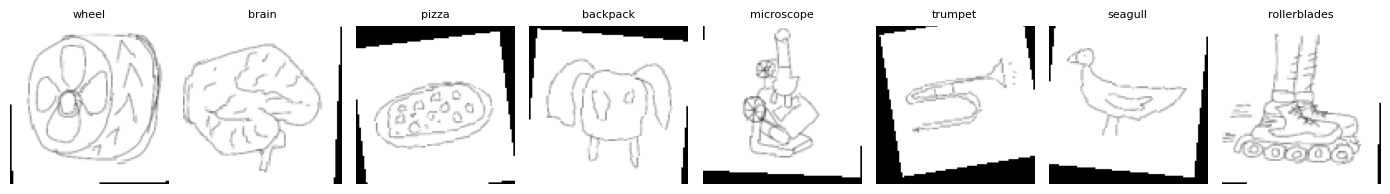

In [37]:
# %% 8 - Show Sample Images
def show_samples(loader, class_names, num_samples=8):
    images, labels = next(iter(loader))

    plt.figure(figsize=(14, 4))
    for i in range(num_samples):
        plt.subplot(1, num_samples, i + 1)
        img = images[i].squeeze().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(class_names[labels[i].item()], fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_loader, class_names)

In [38]:
# %% 9 - Define CNN Model
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 96 -> 48

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 48 -> 24

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 24 -> 12

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),   # 12 -> 6

            # Block 5
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU()
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x

model = CNN(num_classes=num_classes).to(device)

In [39]:
# %% 10 - Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=5,
    T_mult=2
)

In [40]:
# %% 11 - Training Function
def train_model(model, train_loader, val_loader, epochs):
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # ----- TRAIN -----
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (preds == labels).sum().item()

        avg_train_loss = running_train_loss / len(train_loader)
        train_acc = 100 * train_correct / train_total

        # ----- VALIDATION -----
        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * val_correct / val_total

        scheduler.step()

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_weights = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f}"
        )

    model.load_state_dict(best_weights)
    return train_losses, val_losses, train_accs, val_accs

In [1]:
# %% 12 - Train Model
train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    epochs=num_epochs
)

print("Training Finished!")

NameError: name 'train_model' is not defined

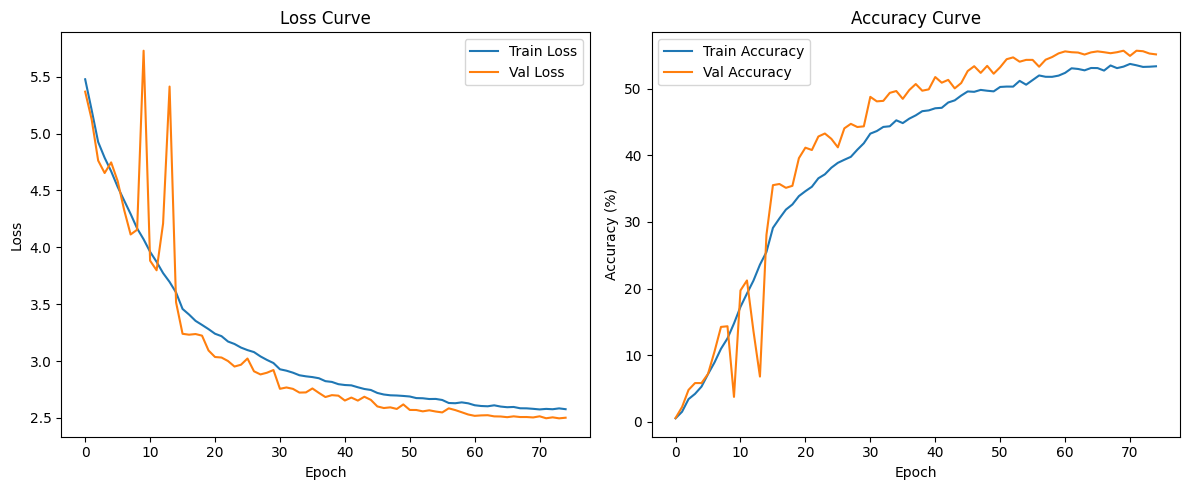

In [27]:
# %% 13 - Plot Loss and Accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curve")
plt.legend()

plt.tight_layout()
plt.show()

In [28]:
# %% 14 - Evaluate on Validation Set
def evaluate_model(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy: {acc:.2f}%")
    return acc

val_accuracy = evaluate_model(model, val_loader)

Accuracy: 55.70%


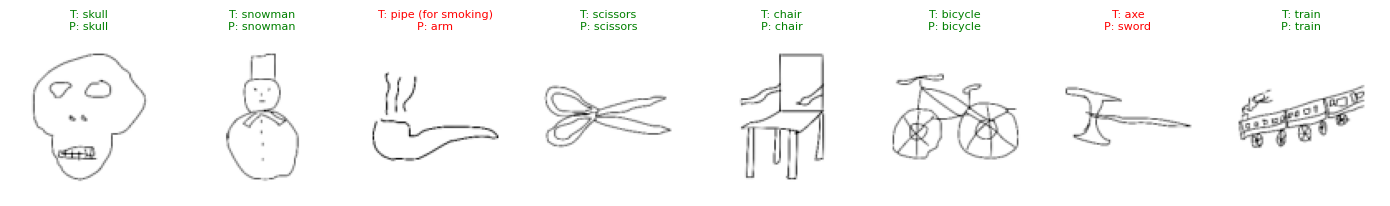

In [29]:
# %% 15 - Show Predictions
def show_predictions(model, loader, class_names, num_samples=8):
    model.eval()
    images, labels = next(iter(loader))

    plt.figure(figsize=(14, 4))
    for i in range(num_samples):
        image = images[i].unsqueeze(0).to(device)
        true_label = labels[i].item()

        with torch.no_grad():
            output = model(image)
            pred_label = torch.argmax(output, dim=1).item()

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i].squeeze().numpy(), cmap='gray')
        plt.title(
            f"T: {class_names[true_label]}\nP: {class_names[pred_label]}",
            color="green" if true_label == pred_label else "red",
            fontsize=8
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions(model, val_loader, class_names)

In [ ]:
# %% 16 - Save Model
save_path = "/content/drive/MyDrive/drawing_cnn_model.pth"
torch.save(model.state_dict(), save_path)
print("Model saved to:", save_path)